## Use barcharts and heatmaps to visualize patterns in your data
IGN Game Reviews provide scores from experts for the most recent game releases, ranging from 0 (Disaster) to 10 (Masterpiece).
<img src="https://i.imgur.com/Oh06Fu1.png">




## Load the data
1. Read the IGN data file into a dataframe named `ign_scores`.  
2. Use the `"Platform"` column to label the rows.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

IGN="https://raw.githubusercontent.com/csbfx/advpy122-data/master/ign_scores.csv"

ign_scores = pd.read_csv(IGN, index_col=0)

ign_scores

,Action,"Action, Adventure",Adventure,Fighting,Platformer,Puzzle,RPG,Racing,Shooter,Simulation,Sports,Strategy
Platform,,,,,,,,,,,,
Dreamcast,6.882857,7.511111,6.281818,8.200000,8.340000,8.088889,7.700000,7.042500,7.616667,7.628571,7.272222,6.433333
Game Boy Advance,6.373077,7.507692,6.057143,6.226316,6.970588,6.532143,7.542857,6.657143,6.444444,6.928571,6.694444,7.175000
Game Boy Color,6.272727,8.166667,5.307692,4.500000,6.352941,6.583333,7.285714,5.897436,4.500000,5.900000,5.790698,7.400000
GameCube,6.532584,7.608333,6.753846,7.422222,6.665714,6.133333,7.890909,6.852632,6.981818,8.028571,7.481319,7.116667
Nintendo 3DS,6.670833,7.481818,7.414286,6.614286,7.503448,8.000000,7.719231,6.900000,7.033333,7.700000,6.388889,7.900000
Nintendo 64,6.649057,8.250000,7.000000,5.681250,6.889655,7.461538,6.050000,6.939623,8.042857,5.675000,6.967857,6.900000
Nintendo DS,5.903608,7.240000,6.259804,6.320000,6.840000,6.604615,7.222619,6.038636,6.965217,5.874359,5.936667,6.644737
Nintendo DSi,6.827027,8.500000,6.090909,7.500000,7.250000,6.810526,7.166667,6.563636,6.500000,5.195652,5.644444,6.566667
PC,6.805791,7.334746,7.136798,7.166667,7.410938,6.924706,7.759930,7.032418,7.084878,7.104889,6.902424,7.310207


In [2]:
ign_scores.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21 entries, Dreamcast to iPhone
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Action             21 non-null     float64
 1   Action, Adventure  21 non-null     float64
 2   Adventure          21 non-null     float64
 3   Fighting           21 non-null     float64
 4   Platformer         21 non-null     float64
 5   Puzzle             21 non-null     float64
 6   RPG                21 non-null     float64
 7   Racing             21 non-null     float64
 8   Shooter            21 non-null     float64
 9   Simulation         21 non-null     float64
 10  Sports             21 non-null     float64
 11  Strategy           21 non-null     float64
dtypes: float64(12)
memory usage: 2.1+ KB


## Problem 1
Use the dataframe ign_scores and write one line of code to determine the highest score received by any kind of games on the Wii platform?

In [3]:
max = ign_scores.loc['Wii'].max()
print("Highest score received on Wii games:", max)

Highest score received on Wii games: 7.410344827586206


## Problem 2
Use the dataframe `ign_scores` to determine which genre has the lowest score for the `PlayStation Vita` platform.

In [4]:
worst_genre = ign_scores.loc['PlayStation Vita'].idxmin()
print("Lowest genre score for PlayStation Vita:", worst_genre)

Lowest genre score for PlayStation Vita: Simulation


## Problem 3
Your instructor's favorite video game has been Mario Kart Wii, a racing game released for the Wii platform in 2008. And, IGN agrees with her that it is a great game -- their rating for this game is a whopping 8.9! Inspired by the success of this game, your instructor is considering creating your very own racing game for the Wii platform. Perform the following analyses to help her determine which platform she should focus on.

1. Create a bar chart that shows the score for *Racing* games, for each platform. Your chart should have one bar for each platform. Provide a meaningful title to the plot.

2. Based on the bar chart, do you expect a racing game for the **Wii** platform to receive a high rating?  If not, use the pandas to find out from the dataframe `ign_scores` which gaming platform is the best for racing game?

<Axes: title={'center': 'Ratings of Racing Games on Each Platform'}, xlabel='Racing', ylabel='Platform'>

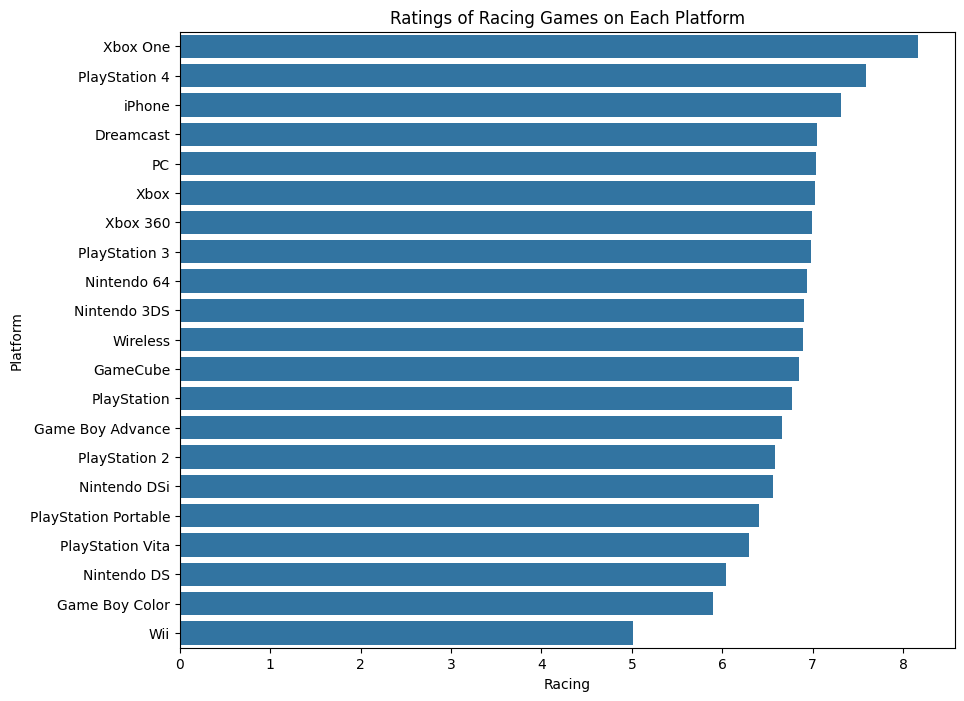

In [5]:

# Set the width and height of the figure
plt.figure(figsize=(10, 8))
plt.title("Ratings of Racing Games on Each Platform")

order = ign_scores['Racing'].sort_values(ascending=False).index

sns.barplot(data=ign_scores,
            x=ign_scores['Racing'],
            y=ign_scores.index,
            order=order
            )

In [6]:

## Use ign_scores to determine which gaming platform is the best
top_racing = ign_scores['Racing'].idxmax()
print("Best platform for racing:", top_racing)

Best platform for racing: Xbox One


#### Problem 4
Since your instructor's gaming interests are pretty broad, you can help her decide to use the IGN scores to determine the choice of genre and platform.

1. Create a heatmap using the IGN scores by genre and platform and include the scores in the cells of the heatmap.
2. Base on the heatmap, which combination of genre and platform receives the highest average ratings?  Which combination receives the lowest average rankings? Write the answers in a markdown cell.

<Axes: ylabel='Platform'>

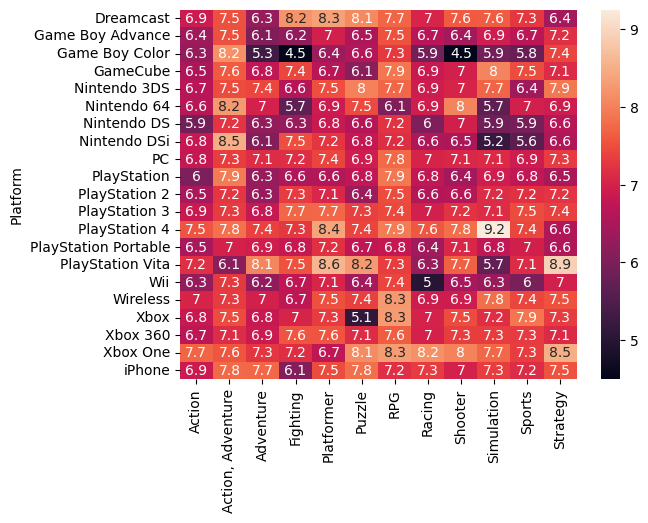

In [7]:
## Create a heatmap
sns.heatmap(data=ign_scores,
            annot=True)

### Answer
The combination of platform and genre that receives the highest average rating is the PlayStation 4 and simulation games with an average score of 9.2. The combination of platform and genre that receives the lowest average rating is the Game Boy Color and fighting or shooter games with an average score of 4.5

## Problem 5
Use the Pokemon dataset to create a clustermap with color. First, filter the dataframe to only keep data with `Type 1` equals to following values: `Water`, `Normal`, `Grass`, `Bug` and `Psychic`. Annotate the dendrogram using different colors for these five different `Type 1` values. Use `Name` as the index.

pokemon_data is in https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Text(0.5, 1.05, 'Clustermap of Pokemon by Type and Stats')

<Figure size 1000x800 with 0 Axes>

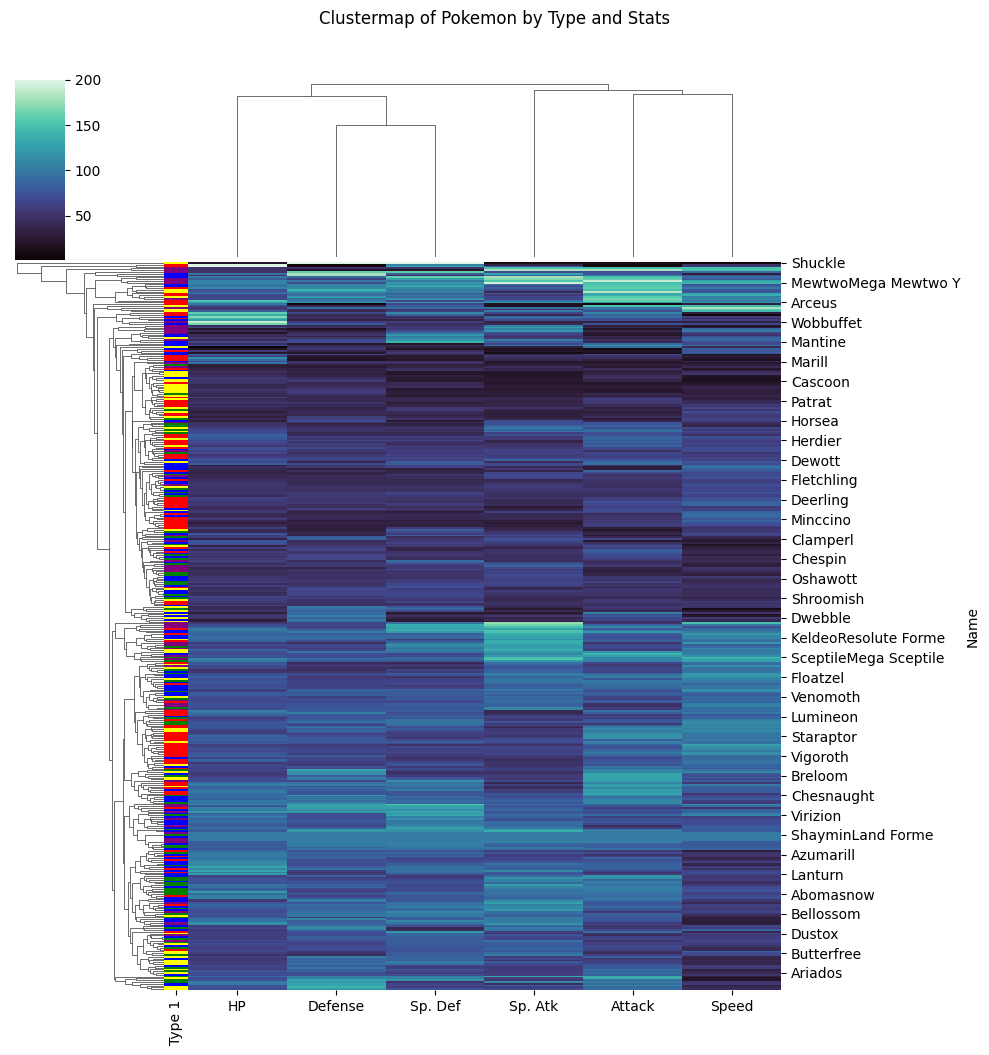

In [8]:
# Problem 5
import scipy

pokemon = pd.read_csv("https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv",
                      index_col=1)

keep_list = {'Water', 'Normal', 'Grass', 'Bug', 'Psychic'}

pokemon_filtered = pokemon[pokemon['Type 1'].isin(keep_list)]

numeric_pokemon = pokemon_filtered.select_dtypes(include='number').drop(columns=['#','Generation','Total'])

color = {'Water': 'blue', 'Normal': 'red', 'Grass': 'green', 'Bug': 'yellow', 'Psychic': 'purple'}
row_colors = pokemon_filtered['Type 1'].map(color)

plt.figure(figsize=(10, 8))
sns.clustermap(data=numeric_pokemon,
               cmap='mako',
               row_colors=row_colors,
               vmax=200
               )
plt.suptitle('Clustermap of Pokemon by Type and Stats', y= 1.05, ha='center')